image_file 타입: <class 'PIL.JpegImagePlugin.JpegImageFile'>
배열 타입: <class 'numpy.ndarray'>
배열 형태: 3D, (437, 705, 3)
높이 픽셀: 437
너비 픽셀: 705
채널 수: 3
[R, G, B]: [216 157   3]


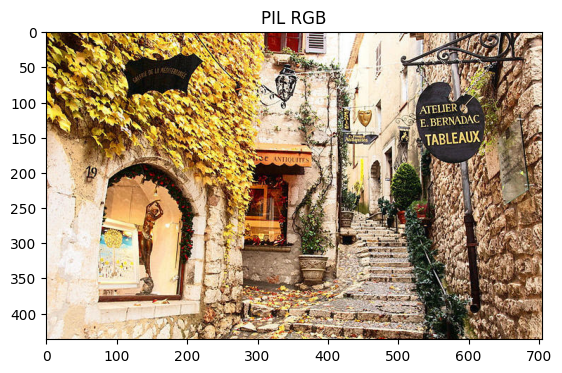

In [1]:
import numpy as np  # 넘파이 배열 처리 라이브러리 임포트
from PIL import Image  # PIL 이미지 처리 라이브러리 임포트
import matplotlib.pyplot as plt  # Matplotlib 시각화 라이브러리 임포트

# PIL을 사용하여 이미지 파일 열기 (ImageFile 객체 생성)
image_path = "../images/photo1.jpg" 
image_file = Image.open(image_path) 
 
print(f"image_file 타입: {type(image_file)}")

# ImageFile 객체로부터 이미지 데이터를 읽고 
# 넘파이 3D 배열로 변환 (높이, 너비, 채널)
ndarray = np.array(image_file)

print(f"배열 타입: {type(ndarray)}")
print(f"배열 형태: {ndarray.ndim}D, {ndarray.shape}") # (높이, 너비, 채널)
print(f"높이 픽셀: {ndarray.shape[0]}") # 높이 픽셀 수는 배열의 첫 번째 차원 크기
print(f"너비 픽셀: {ndarray.shape[1]}") # 너비 픽셀 수는 배열의 두 번째 차원 크기
print(f"채널 수: {ndarray.shape[2]}") # 채널 수는 배열의 세 번째 차원 크기 (예: RGB는 3, RGBA는 4)
print(f"[R, G, B]: {ndarray[0, 0]}")

plt.title("PIL RGB")  # 그래프 제목 설정
# PIL은 기본적으로 RGB 순서로 이미지를 로드함
# RGB 순서의 이미지를 화면에 표시
plt.imshow(ndarray)
# 그래프 보기(.py 파일로 작성했을 경우에 필요)
plt.show()  

배열 형태: (16, 200, 300, 3)


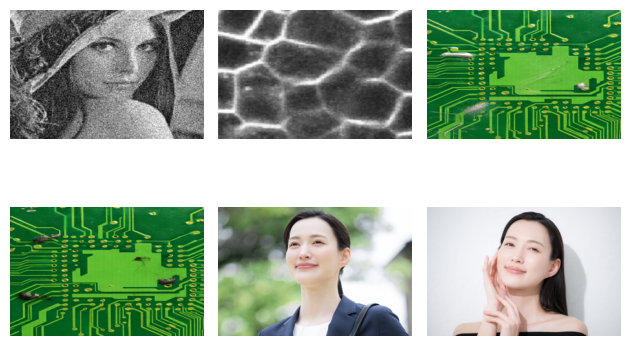

In [2]:
import os # 파일 및 디렉토리 작업을 위한 라이브러리 임포트
from PIL import Image  # 이미지 파일을 읽고 처리하기 위한 라이브러리
import numpy as np  # 배열 처리를 위한 라이브러리
import matplotlib.pyplot as plt  # 이미지 시각화를 위한 라이브러리

# 이미지 디렉토리에서 데이터셋을 생성하는 함수 정의
def getImageDataset(image_dir):
    # 디렉토리 내 모든 파일 이름 가져오기
    file_names = os.listdir(image_dir)
    
    # 이미지를 저장할 리스트 초기화
    image_file_list = [] 
    
    # 디렉토리 내 모든 파일에 대해 반복하면서 이미지 로드 및 처리
    # ndarray 데이터셋을 만들려면 크기가 동일해야 하므로 
    # 모든 이미지를 300x200 크기로 리사이즈
    for file_name in file_names:
        # 이미지 파일 경로 얻기
        file_path = os.path.join(image_dir, file_name)
        # 이미지 파일 열기
        image_file = Image.open(file_path)
        # RGBA 이미지를 RGB로 변환 (채널 수를 3으로 맞춤)
        image_file = image_file.convert("RGB")
        # 모든 이미지를 동일한 크기로 리사이즈
        image_file = image_file.resize((300, 200))
        # PIL Image 객체를 넘파이 배열로 변환
        image_file = np.array(image_file)
        # 변환된 이미지 배열을 리스트에 추가
        image_file_list.append(image_file)
    
    # 리스트를 numpy 배열로 변환하고 반환
    dataset = np.array(image_file_list)
    return dataset

if __name__ == "__main__":
    # 이미지가 저장된 디렉토리 경로 설정
    image_dir = "../images"

    # 데이터셋 생성
    dataset = getImageDataset(image_dir)
    print(f"배열 형태: {dataset.shape}") 

    # 2행 3열 그리드로 6개의 이미지 표시
    for i in range(6):
        # 서브플롯 위치 지정 (2행 3열의 i+1번째)
        plt.subplot(2, 3, (i+1))
        # i번째 이미지 표시
        plt.imshow(dataset[i])
        # 축 눈금과 레이블 제거
        plt.axis("off") 
        
    # 그래프의 간격을 자동으로 조정하여 레이아웃을 깔끔하게 만듦
    plt.tight_layout()
    
    # 그래프 보기(.py 파일로 작성했을 경우에 필요)
    plt.show() 
